In [1]:
# Exploratory Data Analysis — Home Credit Default Risk

# Big Data course final project — PySpark-based EDA on the Home Credit dataset
# (307,511 customers, 7 relational tables, ~2.5 GB).

# **Student:** Nguyễn Việt Phương | **MSSV:** 24022431

In [2]:
!pip install pyspark==3.5.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 20.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/BigData/data"

Mounted at /content/drive


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("eda-credit-risk")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 3.5.0


In [5]:
tables = {
    "application_train": f"{DATA_PATH}/application_train.csv",
    "bureau": f"{DATA_PATH}/bureau.csv",
    "bureau_balance": f"{DATA_PATH}/bureau_balance.csv",
    "previous_application": f"{DATA_PATH}/previous_application.csv",
    "installments_payments": f"{DATA_PATH}/installments_payments.csv",
    "credit_card_balance": f"{DATA_PATH}/credit_card_balance.csv",
    "POS_CASH_balance": f"{DATA_PATH}/POS_CASH_balance.csv",
}

overview = []
for name, path in tables.items():
    df = spark.read.csv(path, header=True, inferSchema=True)
    overview.append({"table": name, "rows": df.count(), "columns": len(df.columns)})

import pandas as pd
overview_df = pd.DataFrame(overview)
print(overview_df.to_string(index=False))

                table     rows  columns
    application_train   307511      122
               bureau  1716428       17
       bureau_balance 27299925        3
 previous_application  1670214       37
installments_payments 13605401        8
  credit_card_balance  3840312       23
     POS_CASH_balance 10001358        8


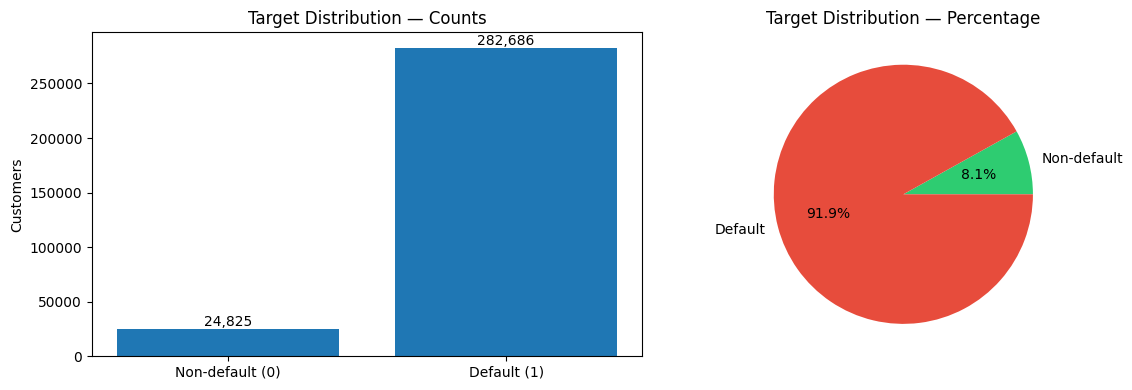


Class imbalance ratio: 1 : 0.1


In [6]:
import matplotlib.pyplot as plt

app = spark.read.csv(f"{DATA_PATH}/application_train.csv", header=True, inferSchema=True)

target_counts = app.groupBy("TARGET").count().toPandas()
target_counts["pct"] = target_counts["count"] / target_counts["count"].sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["Non-default (0)", "Default (1)"], target_counts["count"])
ax[0].set_title("Target Distribution — Counts")
ax[0].set_ylabel("Customers")
for i, v in enumerate(target_counts["count"]):
    ax[0].text(i, v, f"{v:,}", ha='center', va='bottom')

ax[1].pie(target_counts["count"], labels=["Non-default", "Default"],
          autopct='%1.1f%%', colors=["#2ecc71", "#e74c3c"])
ax[1].set_title("Target Distribution — Percentage")
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: 1 : {target_counts.loc[0, 'count'] / target_counts.loc[1, 'count']:.1f}")

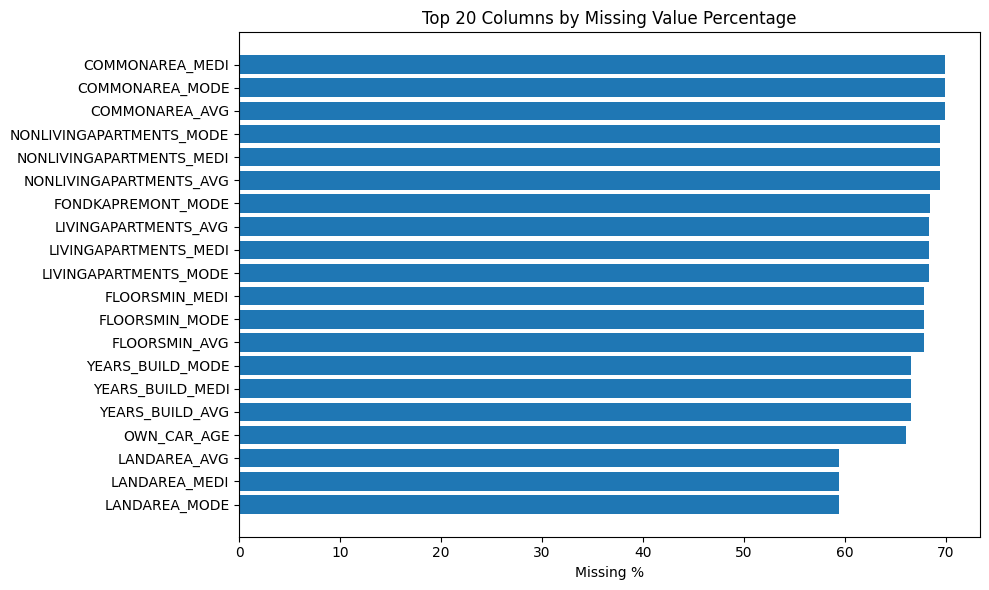

In [7]:
from pyspark.sql.functions import col, isnan

total = app.count()
missing = []
for c in app.columns:
    if c in ["SK_ID_CURR", "TARGET"]:
        continue
    miss = app.filter(col(c).isNull()).count()
    if miss > 0:
        missing.append({"column": c, "missing_pct": miss / total * 100})

missing_df = pd.DataFrame(missing).sort_values("missing_pct", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(missing_df["column"], missing_df["missing_pct"])
plt.xlabel("Missing %")
plt.title("Top 20 Columns by Missing Value Percentage")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

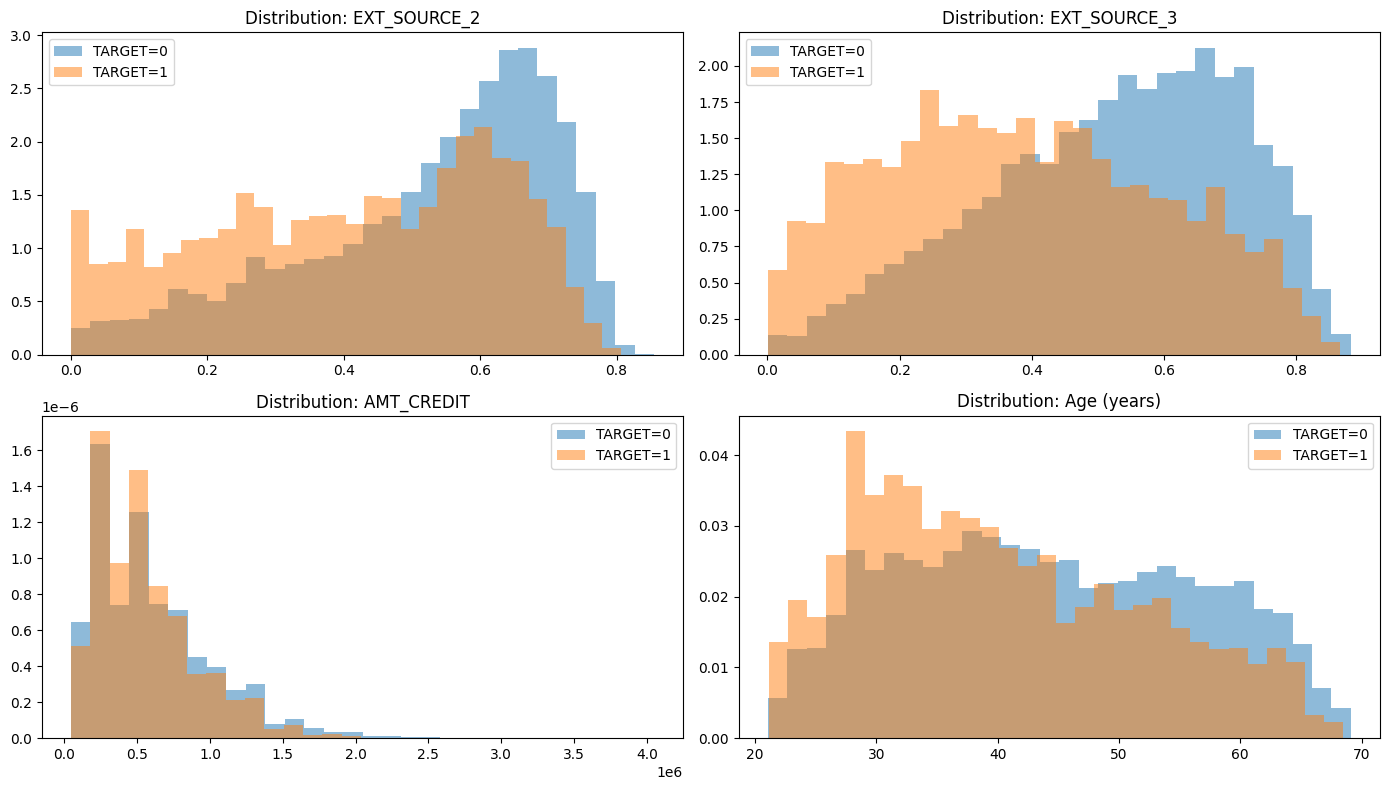

In [8]:
key_features = ["EXT_SOURCE_2", "EXT_SOURCE_3", "AMT_CREDIT", "DAYS_BIRTH"]
sample = app.select(["TARGET"] + key_features).sample(0.1, seed=42).toPandas()
sample["DAYS_BIRTH"] = -sample["DAYS_BIRTH"] / 365

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), key_features):
    feat_label = "Age (years)" if feat == "DAYS_BIRTH" else feat
    for target_val in [0, 1]:
        data = sample[sample["TARGET"] == target_val][feat].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=f"TARGET={target_val}", density=True)
    ax.set_title(f"Distribution: {feat_label}")
    ax.legend()
plt.tight_layout()
plt.show()

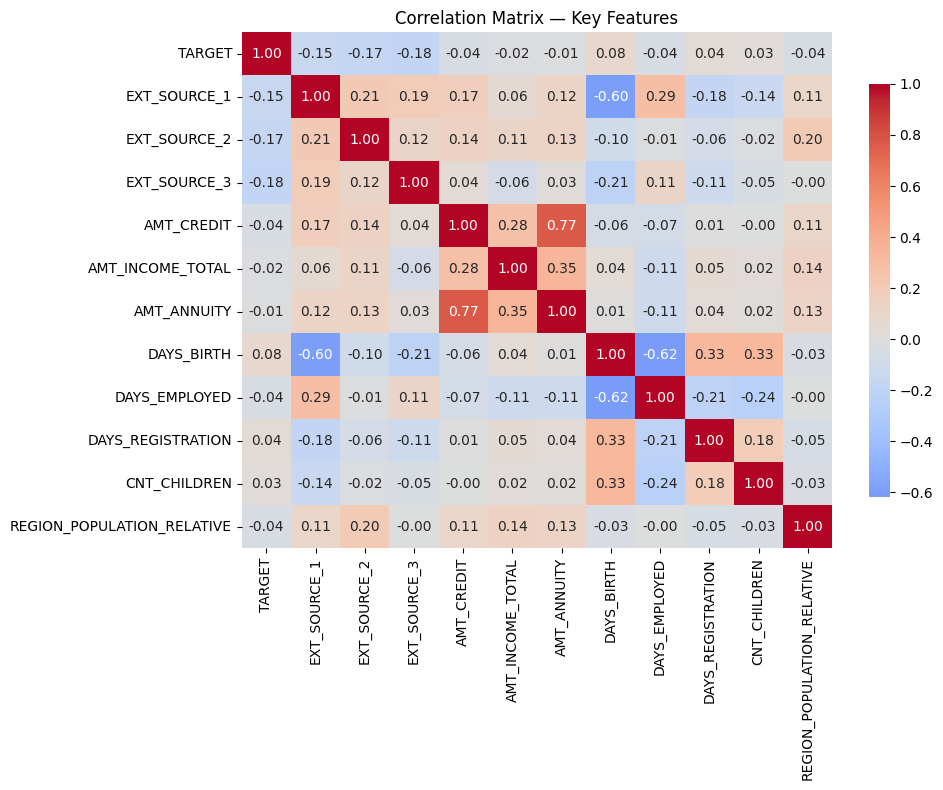


Features most correlated with TARGET:
EXT_SOURCE_3                  0.184544
EXT_SOURCE_2                  0.166553
EXT_SOURCE_1                  0.152943
DAYS_BIRTH                    0.082836
DAYS_REGISTRATION             0.042560
DAYS_EMPLOYED                 0.041166
REGION_POPULATION_RELATIVE    0.038733
AMT_CREDIT                    0.036306
CNT_CHILDREN                  0.025586
AMT_INCOME_TOTAL              0.020242
Name: TARGET, dtype: float64


In [9]:
import seaborn as sns

numeric_features = [
    "TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "CNT_CHILDREN", "REGION_POPULATION_RELATIVE",
]
corr_data = app.select(numeric_features).sample(0.2, seed=42).toPandas()
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Key Features")
plt.tight_layout()
plt.show()

print("\nFeatures most correlated with TARGET:")
print(corr_matrix["TARGET"].drop("TARGET").abs().sort_values(ascending=False).head(10))

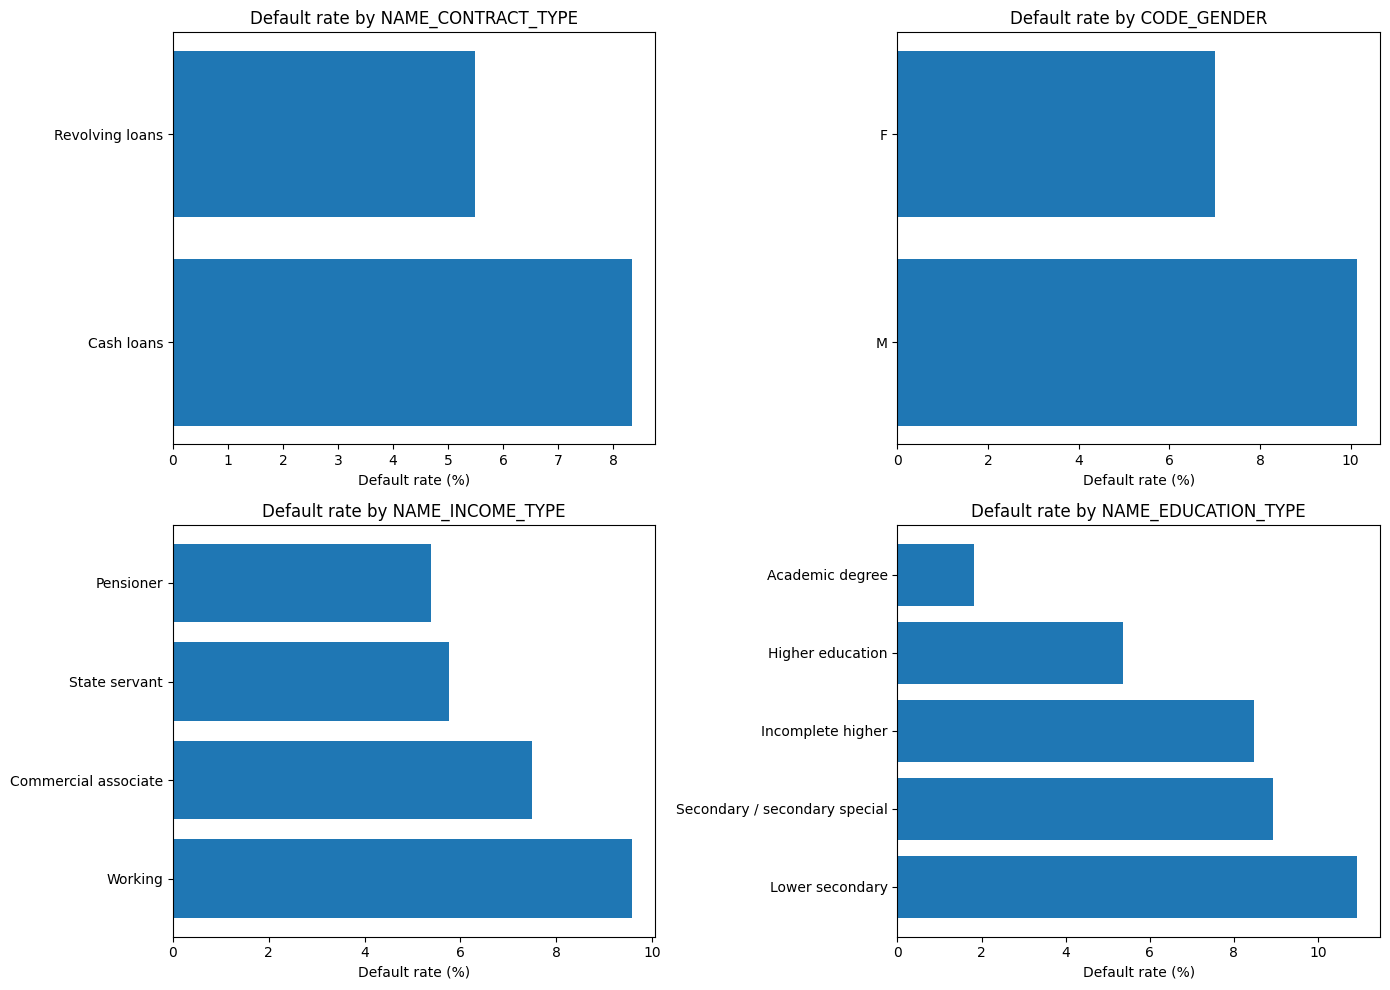

In [10]:
categorical = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), categorical):
    rates = (app.groupBy(feat)
             .agg(F.avg("TARGET").alias("default_rate"), F.count("*").alias("count"))
             .orderBy("default_rate", ascending=False)
             .toPandas())
    rates = rates[rates["count"] > 100]
    ax.barh(rates[feat].astype(str), rates["default_rate"] * 100)
    ax.set_xlabel("Default rate (%)")
    ax.set_title(f"Default rate by {feat}")
plt.tight_layout()
plt.show()

In [11]:
bureau = spark.read.csv(f"{DATA_PATH}/bureau.csv", header=True, inferSchema=True)
print(f"Bureau table: {bureau.count():,} rows")

bureau_agg = bureau.groupBy("SK_ID_CURR").agg(
    F.count("*").alias("BUREAU_LOAN_COUNT"),
    F.sum(F.when(F.col("CREDIT_ACTIVE") == "Active", 1).otherwise(0)).alias("BUREAU_ACTIVE"),
    F.avg("CREDIT_DAY_OVERDUE").alias("BUREAU_OVERDUE_MEAN"),
    F.sum("AMT_CREDIT_SUM").alias("BUREAU_DEBT_TOTAL"),
)

master = app.join(bureau_agg, on="SK_ID_CURR", how="left")
print(f"After join: {master.count():,} rows × {len(master.columns)} cols")
print(f"  → Added {len(master.columns) - len(app.columns)} new features from bureau")

Bureau table: 1,716,428 rows
After join: 307,511 rows × 126 cols
  → Added 4 new features from bureau


In [12]:
from scipy.stats import kruskal

features_to_test = [
    "EXT_SOURCE_2", "EXT_SOURCE_3", "AMT_CREDIT", "AMT_INCOME_TOTAL",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "REGION_POPULATION_RELATIVE",
    "AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_FAM_MEMBERS",
]

sample = app.select(features_to_test + ["TARGET"]).sample(0.3, seed=42).toPandas()

results = []
for feat in features_to_test:
    valid = sample[[feat, "TARGET"]].dropna()
    g0 = valid.loc[valid["TARGET"] == 0, feat]
    g1 = valid.loc[valid["TARGET"] == 1, feat]
    h, p = kruskal(g0, g1)
    results.append({"feature": feat, "H_statistic": h, "p_value": p, "significant": p < 0.05})

ranking = pd.DataFrame(results).sort_values("H_statistic", ascending=False)
print("Kruskal-Wallis non-parametric feature ranking:\n")
print(ranking.to_string(index=False))

print("""
References:
- Predicting mortgage credit defaults in Morocco (2025), Discover AI, Springer
- Ashofteh & Bravo (2021), Expert Systems with Applications

Why Kruskal-Wallis over ANOVA?
Credit risk features (income, credit amount) are typically skewed and
non-normal — violating ANOVA assumptions. Kruskal-Wallis is rank-based
and makes no distributional assumptions.
""")

Kruskal-Wallis non-parametric feature ranking:

                   feature  H_statistic       p_value  significant
              EXT_SOURCE_2  2143.237230  0.000000e+00         True
              EXT_SOURCE_3  2129.672462  0.000000e+00         True
                DAYS_BIRTH   605.967687 8.429276e-134         True
           AMT_GOODS_PRICE   112.544397  2.715165e-26         True
REGION_POPULATION_RELATIVE    92.966419  5.318921e-22         True
             DAYS_EMPLOYED    64.880050  7.959891e-16         True
                AMT_CREDIT    41.445225  1.212203e-10         True
          AMT_INCOME_TOTAL    39.552549  3.193492e-10         True
           CNT_FAM_MEMBERS    10.494890  1.197051e-03         True
               AMT_ANNUITY     0.022471  8.808401e-01        False

References:
- Predicting mortgage credit defaults in Morocco (2025), Discover AI, Springer
- Ashofteh & Bravo (2021), Expert Systems with Applications

Why Kruskal-Wallis over ANOVA?
Credit risk features (income, c